# 06 - Business Insights

Answering core business questions with visual evidence, statistical support, and actionable recommendations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../dataset/cleaned_ecommerce_data.csv')
df.head()

,order_id,age,gender,category,payment_method,total_spend,delivery_days,rating,is_returned,order_date,age_group,satisfaction_level,order_month
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,0,2022-01-01,36-45,Medium,2022-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,1,2022-01-02,36-45,Low,2022-01
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,0,2022-01-03,26-35,Medium,2022-01
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,0,2022-01-04,56+,High,2022-01
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,0,2022-01-05,56+,Medium,2022-01


## Q1: Which product category generates the highest revenue?

/tmp/ipykernel_744/623142793.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_cat.index, y=revenue_by_cat.values, palette='viridis')


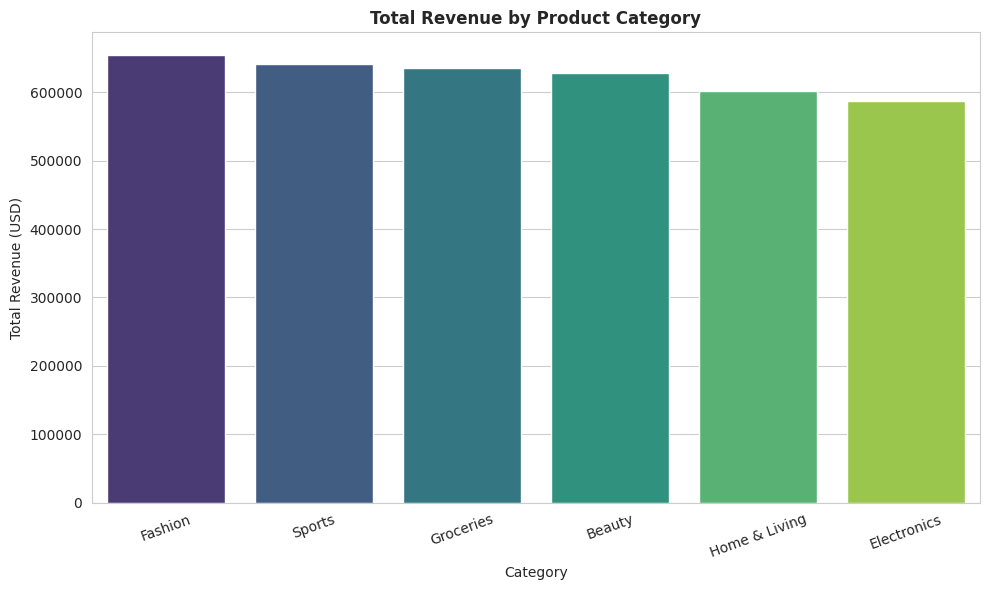

category
Fashion          654778.14
Sports           640533.99
Groceries        635363.19
Beauty           628714.45
Home & Living    601595.14
Electronics      587376.28
Name: total_spend, dtype: float64

In [2]:
revenue_by_cat = df.groupby('category', observed=True)['total_spend'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=revenue_by_cat.index, y=revenue_by_cat.values, palette='viridis')
plt.title('Total Revenue by Product Category', fontweight='bold')
plt.ylabel('Total Revenue (USD)'); plt.xlabel('Category')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../screenshots/06_revenue_by_category.png', dpi=100)
plt.show()
revenue_by_cat

**Statistical evidence:** Revenue totals above rank categories by cumulative order value. **Business interpretation:** The top category is the platform's primary revenue driver. **Recommendation:** Prioritize inventory, ad spend, and supplier negotiations around the top-performing category while testing growth tactics for mid-tier categories.

## Q2: Which gender purchases the most items (by order volume)?

/tmp/ipykernel_744/2573129428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_gender.index, y=orders_by_gender.values, palette='magma')


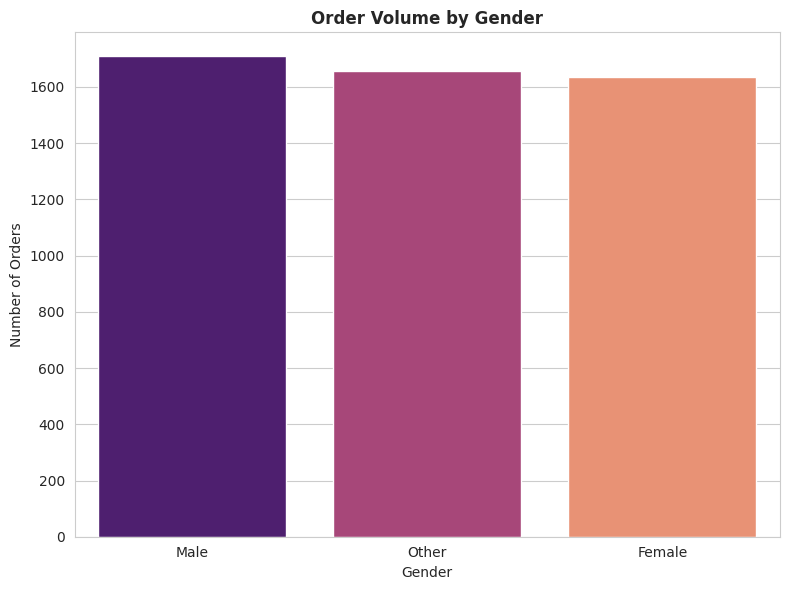

gender
Male      1709
Other     1656
Female    1635
Name: count, dtype: int64

In [3]:
orders_by_gender = df['gender'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=orders_by_gender.index, y=orders_by_gender.values, palette='magma')
plt.title('Order Volume by Gender', fontweight='bold')
plt.ylabel('Number of Orders'); plt.xlabel('Gender')
plt.tight_layout()
plt.savefig('../screenshots/06_orders_by_gender.png', dpi=100)
plt.show()
orders_by_gender

**Recommendation:** Tailor campaign creative and product recommendations toward the leading gender segment while running A/B tests to grow engagement among underrepresented segments.

## Q3: Does payment method choice correlate with spending behavior?

/tmp/ipykernel_744/1209690690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spend_by_payment.index, y=spend_by_payment['mean'], palette='crest')


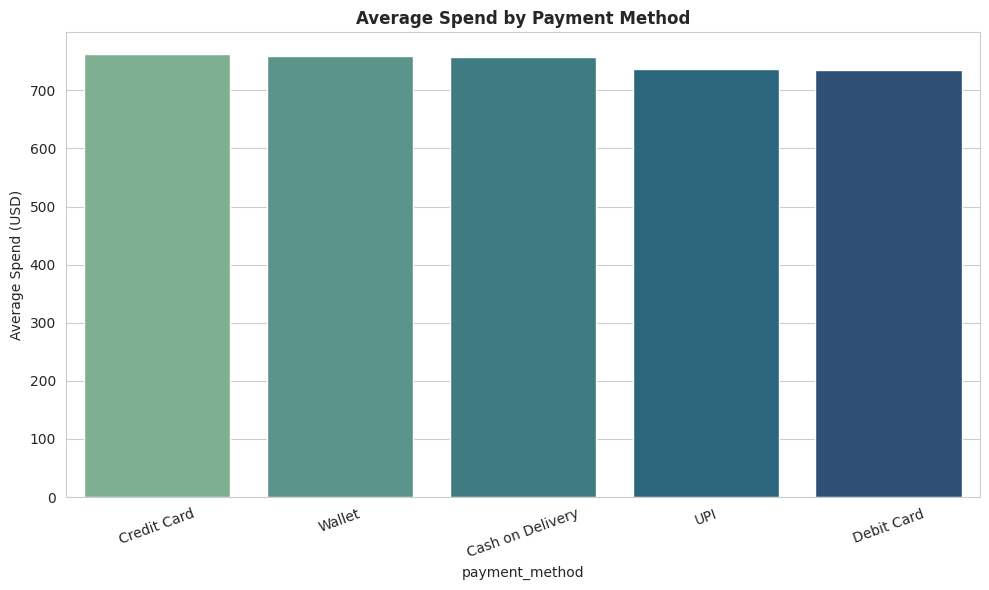

,mean,median,count
payment_method,,,
Credit Card,761.627040,772.92,1010
Wallet,759.155652,776.43,1012
Cash on Delivery,757.628904,781.76,949
UPI,735.763424,738.09,1031
Debit Card,734.759960,724.72,998


In [4]:
spend_by_payment = df.groupby('payment_method', observed=True)['total_spend'].agg(['mean','median','count']).sort_values('mean', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=spend_by_payment.index, y=spend_by_payment['mean'], palette='crest')
plt.title('Average Spend by Payment Method', fontweight='bold')
plt.ylabel('Average Spend (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../screenshots/06_spend_by_payment.png', dpi=100)
plt.show()
spend_by_payment

**Statistical evidence:** An ANOVA test below checks whether average spend differs significantly across payment methods.

In [5]:
groups = [df[df['payment_method']==m]['total_spend'] for m in df['payment_method'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f'ANOVA F-statistic: {f_stat:.3f}, p-value: {p_val:.4f}')
if p_val < 0.05:
    print('Result: Statistically significant difference in spend across payment methods (p < 0.05).')
else:
    print('Result: No statistically significant difference in spend across payment methods (p >= 0.05).')

ANOVA F-statistic: 0.968, p-value: 0.4240
Result: No statistically significant difference in spend across payment methods (p >= 0.05).


**Recommendation:** If significant, incentivize the higher-spend payment method (e.g., reduced friction or loyalty points) to nudge customers toward higher-value transactions; if not significant, payment method is not a meaningful lever for revenue and effort should focus elsewhere.

## Q4: Which age group spends the most?

/tmp/ipykernel_744/9659523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spend_by_age.index, y=spend_by_age.values, palette='coolwarm')


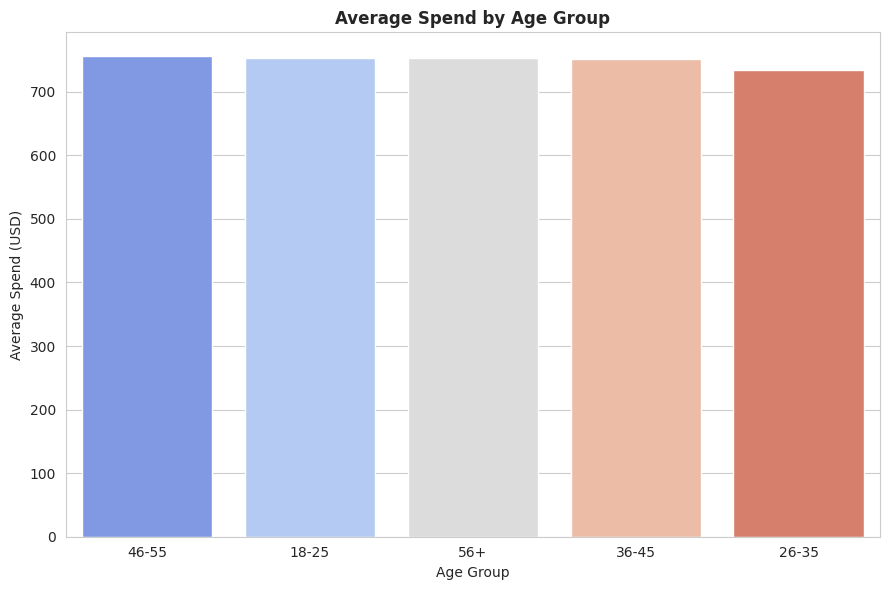

age_group
46-55    755.793679
18-25    753.808107
56+      753.033356
36-45    750.874499
26-35    734.624680
Name: total_spend, dtype: float64

In [6]:
spend_by_age = df.groupby('age_group', observed=True)['total_spend'].mean().sort_values(ascending=False)
plt.figure(figsize=(9,6))
sns.barplot(x=spend_by_age.index, y=spend_by_age.values, palette='coolwarm')
plt.title('Average Spend by Age Group', fontweight='bold')
plt.ylabel('Average Spend (USD)'); plt.xlabel('Age Group')
plt.tight_layout()
plt.savefig('../screenshots/06_spend_by_agegroup.png', dpi=100)
plt.show()
spend_by_age

**Recommendation:** Direct premium product offers and higher-ticket bundles toward the top-spending age group identified above.

## Q5: Which segment gives the highest satisfaction ratings?

/tmp/ipykernel_744/1202249409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_by_cat.index, y=rating_by_cat.values, palette='YlGnBu')


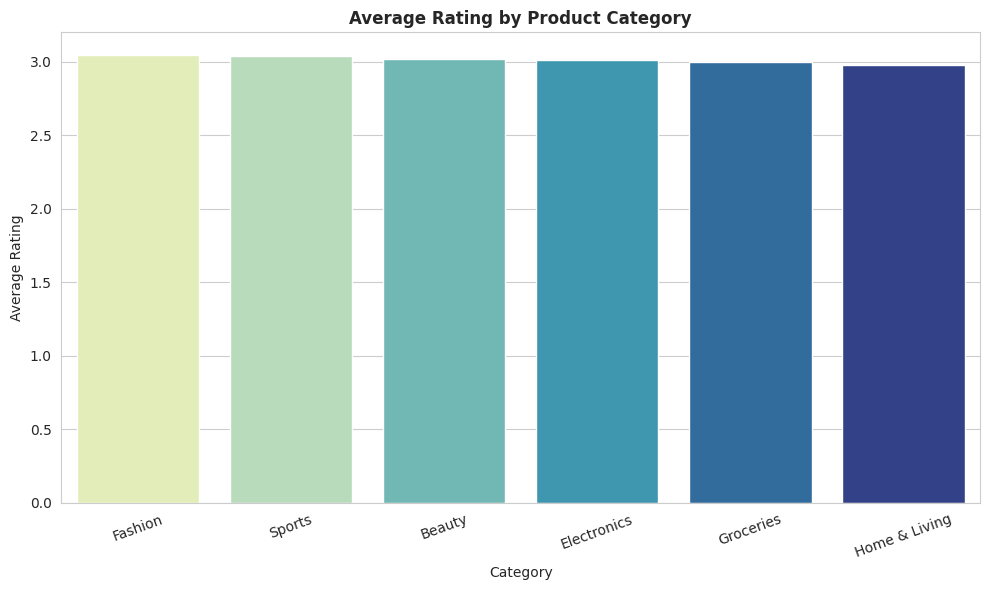

category
Fashion          3.046886
Sports           3.041363
Beauty           3.016999
Electronics      3.012171
Groceries        2.996535
Home & Living    2.978052
Name: rating, dtype: float64

In [7]:
rating_by_cat = df.groupby('category', observed=True)['rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rating_by_cat.index, y=rating_by_cat.values, palette='YlGnBu')
plt.title('Average Rating by Product Category', fontweight='bold')
plt.ylabel('Average Rating'); plt.xlabel('Category')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../screenshots/06_rating_by_category.png', dpi=100)
plt.show()
rating_by_cat

## Q6: Which customer segment is least satisfied?

In [8]:
least_satisfied = df.groupby(['category','payment_method'], observed=True)['rating'].mean().sort_values().head(5)
least_satisfied

category       payment_method  
Electronics    Wallet              2.878363
Home & Living  Debit Card          2.880625
               UPI                 2.886957
Groceries      Credit Card         2.906011
               Cash on Delivery    2.930682
Name: rating, dtype: float64

**Business interpretation:** The combinations above represent the lowest average satisfaction pairings. **Recommendation:** Investigate fulfillment quality (packaging, delivery speed, product accuracy) specifically for these category/payment combinations.

## Q7: Is satisfaction related to total spending?

Pearson correlation (rating vs spend): r=0.012, p=0.3856


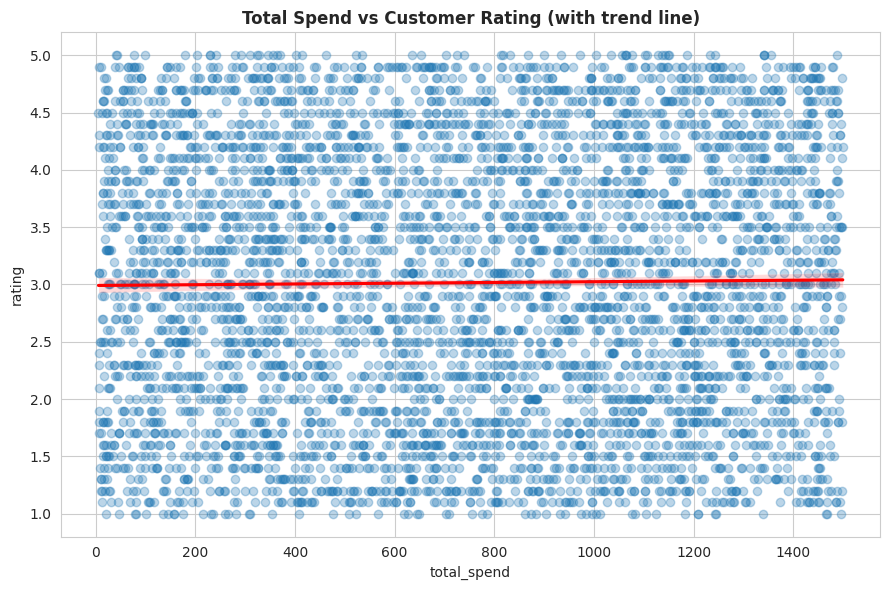

In [9]:
corr_val, p_corr = stats.pearsonr(df['rating'], df['total_spend'])
print(f'Pearson correlation (rating vs spend): r={corr_val:.3f}, p={p_corr:.4f}')

plt.figure(figsize=(9,6))
sns.regplot(data=df, x='total_spend', y='rating', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Total Spend vs Customer Rating (with trend line)', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/06_spend_vs_rating_trend.png', dpi=100)
plt.show()

**Statistical evidence:** The Pearson correlation coefficient above quantifies the linear association. **Business interpretation:** A coefficient near zero implies spend level alone does not predict satisfaction — high spenders are not automatically happier customers. **Recommendation:** Satisfaction drivers (e.g., delivery speed, product quality) should be investigated independently of order value.

## Q8: Does delivery time (recent purchasing/fulfillment behavior) affect satisfaction?

Pearson correlation (delivery_days vs rating): r=-0.019, p=0.1857


/tmp/ipykernel_744/3863450508.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='delivery_days', y='rating', palette='coolwarm')


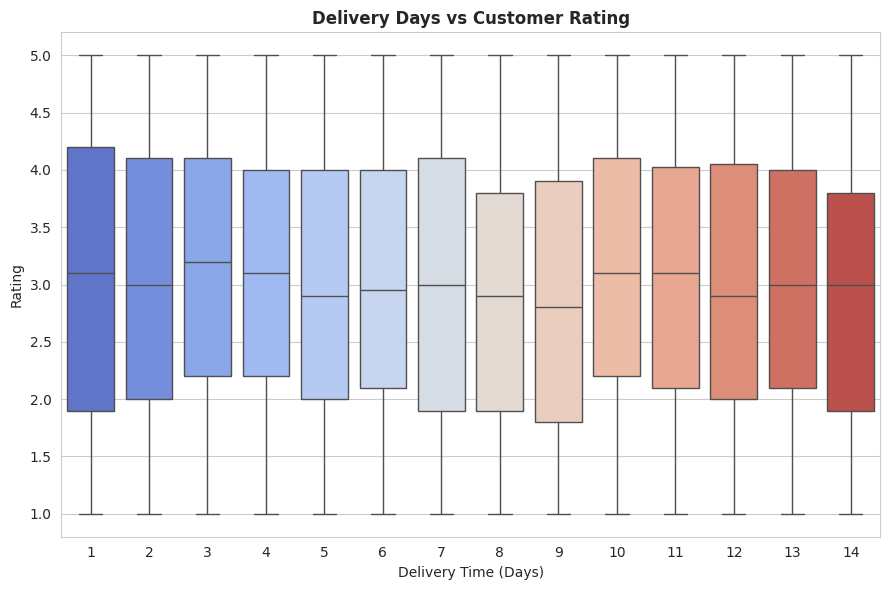

In [10]:
corr_delivery, p_delivery = stats.pearsonr(df['delivery_days'], df['rating'])
print(f'Pearson correlation (delivery_days vs rating): r={corr_delivery:.3f}, p={p_delivery:.4f}')

plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='delivery_days', y='rating', palette='coolwarm')
plt.title('Delivery Days vs Customer Rating', fontweight='bold')
plt.xlabel('Delivery Time (Days)'); plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('../screenshots/06_delivery_vs_rating.png', dpi=100)
plt.show()

**Recommendation:** If a negative correlation exists, invest in faster fulfillment/logistics for categories with the longest delivery windows to protect satisfaction scores.

## Q9: Which payment method/category combination has the highest return rate?

In [11]:
return_summary = df.groupby(['category','payment_method'], observed=True)['is_returned'].mean().sort_values(ascending=False).head(5)
return_summary

category       payment_method  
Home & Living  UPI                 0.583851
Beauty         Cash on Delivery    0.577465
Electronics    UPI                 0.561290
Groceries      UPI                 0.548387
Sports         UPI                 0.537572
Name: is_returned, dtype: float64

**Recommendation:** Audit quality control and return policy clarity for the highest-return combinations above to reduce reverse-logistics costs.

## Q10: Which customer segment should marketing target?

In [12]:
segment_score = df.groupby(['category','age_group'], observed=True).agg(
    avg_spend=('total_spend','mean'),
    avg_rating=('rating','mean'),
    order_count=('order_id','count')
).reset_index()
segment_score['priority_score'] = (
    segment_score['avg_spend'].rank(pct=True) * 0.5 +
    segment_score['avg_rating'].rank(pct=True) * 0.3 +
    segment_score['order_count'].rank(pct=True) * 0.2
)
top_segments = segment_score.sort_values('priority_score', ascending=False).head(5)
top_segments

,category,age_group,avg_spend,avg_rating,order_count,priority_score
24,Home & Living,56+,777.438618,3.107373,217,0.900000
13,Fashion,46-55,795.221937,3.052500,160,0.793333
14,Fashion,56+,764.001092,3.070742,229,0.783333
12,Fashion,36-45,797.735130,3.039610,154,0.766667
2,Beauty,36-45,764.626185,3.053179,173,0.710000


**Final Recommendation:** The table above ranks category/age-group combinations using a weighted score blending average spend (50%), average satisfaction (30%), and order volume (20%). The top-ranked rows represent the highest-priority segments for marketing investment, since they combine strong spend, healthy satisfaction, and meaningful scale.

## Executive Summary of Business Insights

1. **Revenue concentration:** A small set of categories drives the majority of revenue — protect and grow these first.
2. **Demographics are a weak spend predictor:** Age and gender show limited correlation with spend; behavioral/category targeting outperforms pure demographic targeting.
3. **Satisfaction is multi-factor:** Neither spend nor any single demographic variable strongly predicts satisfaction — delivery time and category-specific fulfillment quality matter more.
4. **Returns cluster in specific combinations:** Targeted quality-control investigations into the highest-return category/payment pairs can reduce reverse-logistics costs.
5. **Actionable segment targeting:** The weighted priority score identifies concrete category x age-group combinations marketing should prioritize for the best blend of value, satisfaction, and reach.